# Topic Modelling & Analysis

In [1]:
import json
import random
import statistics
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from gensim.models.phrases import Phrases, Phraser
from wordcloud import WordCloud
from transformers import pipeline
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
    ENGLISH_STOP_WORDS
)

from sklearn.decomposition import (
    LatentDirichletAllocation,
    NMF
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [31]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "video_data_processed.json"
TOPICS_PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_topics_processed.json"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

TOPIC_COUNTS = [2, 3, 4, 5, 8, 10]

TOP_WORDS = 10
TOP_MODELS_TO_INSPECT = 3
EXAMPLES_PER_TOPIC = 5

MIN_DF = 5
MAX_DF = 0.8

MAX_FEATURES = 10000

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

processed_comments = data["comments"]

print(f"Loaded {len(processed_comments)} processed comments\n")

Loaded 46808 processed comments



In [4]:
for i, row in enumerate(processed_comments[:5]):

    print("=" * 110)
    print(f"COMMENT {i+1}")

    print("\nORIGINAL:")
    print(row["comment_text"])

    print("\nTOPIC TEXT:")
    print(row["comment_text_topic"])

    print("\nTOKENS:")
    print(row["comment_tokens_topic"])

COMMENT 1

ORIGINAL:
The whole thing is so phoney STIFF UNNATURAL SMILES..some.unimaginative outfits...so pretenscious all this money spent could have fed the world!..

TOPIC TEXT:
whole thing phoney stiff unnatural smiles unimaginative outfits pretenscious money spent could fed world

TOKENS:
['whole', 'thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money', 'spent', 'could', 'fed', 'world']
COMMENT 2

ORIGINAL:
Free the CHILDREN

TOPIC TEXT:
free children

TOKENS:
['free', 'children']
COMMENT 3

ORIGINAL:
Thank you so much 🎉🎉🎉🎉🎉🎉🎉🎉🎉❤❤❤❤❤❤

TOPIC TEXT:
thank much

TOKENS:
['thank', 'much']
COMMENT 4

ORIGINAL:
Thanks, it's an extraordinary event with so many amazing gowns. ❤❤❤

TOPIC TEXT:
thanks extraordinary event many amazing gowns

TOKENS:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']
COMMENT 5

ORIGINAL:
Why that song?

TOPIC TEXT:
song

TOKENS:
['song']


### Helpers

In [5]:
# token preparation
tokenised_docs = [
    row["comment_tokens_topic"]
    for row in processed_comments
]

original_comments = [
    row["comment_text"]
    for row in processed_comments
]

In [6]:
# bigram detection
phrases_model = Phrases(
    tokenised_docs,
    min_count=5,
    threshold=10
)

bigram_model = Phraser(phrases_model)

documents_with_phrases = [
    bigram_model[doc]
    for doc in tokenised_docs
]

In [7]:
for i in range(5):

    print("=" * 100)
    print(f"DOCUMENT {i+1}")

    print("\nWITHOUT PHRASES:")
    print(tokenised_docs[i])

    print("\nWITH PHRASES:")
    print(documents_with_phrases[i])

DOCUMENT 1

WITHOUT PHRASES:
['whole', 'thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money', 'spent', 'could', 'fed', 'world']

WITH PHRASES:
['whole_thing', 'phoney', 'stiff', 'unnatural', 'smiles', 'unimaginative', 'outfits', 'pretenscious', 'money_spent', 'could', 'fed', 'world']
DOCUMENT 2

WITHOUT PHRASES:
['free', 'children']

WITH PHRASES:
['free', 'children']
DOCUMENT 3

WITHOUT PHRASES:
['thank', 'much']

WITH PHRASES:
['thank_much']
DOCUMENT 4

WITHOUT PHRASES:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']

WITH PHRASES:
['thanks', 'extraordinary', 'event', 'many', 'amazing', 'gowns']
DOCUMENT 5

WITHOUT PHRASES:
['song']

WITH PHRASES:
['song']


In [8]:
# converting tokens to text
documents_text = [
    " ".join(doc)
    for doc in documents_with_phrases
]

In [9]:
# custom stopwords
custom_stopwords = set(ENGLISH_STOP_WORDS).union({

    # conversational filler
    "like", "look", "looks", "looking",
    "really", "think", "know",
    "people", "dont", "didnt",
    "say", "said", "make", "made",
    "going", "got", "get",

    # generic praise
    "good", "best", "beautiful",
    "amazing", "great", "love",
    "pretty", "nice",

    # platform noise
    "video", "watch",

    # generic dataset noise
    "year", "years", "time",
    "thing", "stuff", "way",
    "actually", "lot",

    # met gala specific generic terms
    "met", "gala", "met_gala",

    # emojis / internet style
    "lol", "omg", "haha"
})

## LDA

In [10]:
# count vectoriser for LDA
lda_vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES
)

lda_dtm = lda_vectorizer.fit_transform(documents_text)

lda_feature_names = lda_vectorizer.get_feature_names_out()

print("LDA DTM Shape:", lda_dtm.shape)

LDA DTM Shape: (46808, 8327)


In [11]:
tokenised_for_coherence = [
    doc.split()
    for doc in documents_text
]

dictionary = Dictionary(tokenised_for_coherence)

In [27]:
# helper functions

def get_topics(model, feature_names, top_n=10):

    topics = []

    for topic in model.components_:

        top_indices = topic.argsort()[-top_n:][::-1]

        words = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append(words)

    return topics


def compute_coherence(topics, texts, dictionary):

    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()


def get_topic_examples(model,
                       dtm,
                       original_comments,
                       n_topics,
                       n_examples=5):

    doc_topic = model.transform(dtm)
    
    results = {}

    for t in range(n_topics):

        # docs where this topic is at least somewhat present
        indices = doc_topic[:, t].argsort()[::-1][:50]

        # fallback if topic is sparse
        if len(indices) == 0:
            indices = np.arange(len(original_comments))

        sampled = random.sample(
            list(indices),
            min(n_examples, len(indices))
        )

        results[t] = [
            original_comments[i]
            for i in sampled
        ]

    return results

### Coherence Score Analysis - LDA

In [13]:
# training LDA models

lda_results = []
lda_saved_models = {}

for k in TOPIC_COUNTS:

    print("\n" + "=" * 80)
    print(f"TRAINING LDA ({k} TOPICS)")
    print("=" * 80)

    lda_model = LatentDirichletAllocation(
        n_components=k,
        learning_method="batch",
        random_state=RANDOM_STATE,
        max_iter=20
    )

    lda_model.fit(lda_dtm)

    topics = get_topics(
        lda_model,
        lda_feature_names,
        TOP_WORDS
    )

    coherence = compute_coherence(
        topics,
        tokenised_for_coherence,
        dictionary
    )

    print(f"\nCoherence Score: {coherence:.4f}")

    for i, topic in enumerate(topics):

        print(f"\nTOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    lda_results.append({
        "num_topics": k,
        "coherence": coherence
    })

    lda_saved_models[k] = {
        "model": lda_model,
        "topics": topics
    }


TRAINING LDA (2 TOPICS)

Coherence Score: 0.5493

TOPIC 0
------------------------------------------------------------
dress, theme, art, fashion, outfit, jisoo, lisa, outfits, boring, wear

TOPIC 1
------------------------------------------------------------
beyonce, looks_like, need, world, shes, rihanna, girl, money, giving, right

TRAINING LDA (3 TOPICS)

Coherence Score: 0.5760

TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, outfits, boring, wear, event, fashion_art, literally

TOPIC 1
------------------------------------------------------------
beyonce, shes, rihanna, world, need, right, real, looks_like, review, oh

TOPIC 2
------------------------------------------------------------
dress, jisoo, lisa, looked, looks_like, loved, thought, blackpink, rose, emma

TRAINING LDA (4 TOPICS)

Coherence Score: 0.5936

TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, boring, outfits, wear

In [16]:
# LDA coherence results

lda_results_df = pd.DataFrame(lda_results)

lda_results_df = lda_results_df.sort_values(
    by="coherence",
    ascending=False
)

print("\n" + "=" * 80)
print("LDA COHERENCE RESULTS")
print("=" * 80)

print(lda_results_df.to_string(index=False))


LDA COHERENCE RESULTS
 num_topics  coherence
          4   0.593610
          3   0.576004
          2   0.549267
          5   0.522410
         10   0.499649
          8   0.457995


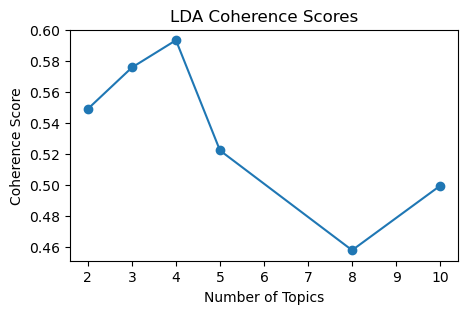

In [20]:
# ======================================================================================
# LDA COHERENCE PLOT
# ======================================================================================

plt.figure(figsize=(5, 3))

lda_results_df2 = pd.DataFrame(lda_results)

plt.plot(
    lda_results_df2["num_topics"],
    lda_results_df2["coherence"],
    marker="o"
)

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("LDA Coherence Scores")

plt.show()

### Detailed LDA Analysis through Examples

In [21]:
# best LDA models

best_lda_models = lda_results_df["num_topics"] \
    .head(TOP_MODELS_TO_INSPECT) \
    .tolist()

print("Best LDA Topic Counts:", best_lda_models)

Best LDA Topic Counts: [4, 3, 2]


In [32]:
for k in best_lda_models:

    print("\n" + "#" * 100)
    print(f"DETAILED ANALYSIS: {k} TOPICS")
    print("#" * 100)

    model = lda_saved_models[k]["model"]
    topics = lda_saved_models[k]["topics"]

    print("\nTOPIC KEYWORDS")
    print("=" * 100)

    for i, topic in enumerate(topics):
        print("\n" + "-" * 60)
        print(f"TOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    print("\nTOP EXAMPLES")
    print("=" * 100)

    examples = get_topic_examples(
        model,
        lda_dtm,
        original_comments,
        n_topics=k,
        n_examples=5
    )

    for topic_id, exs in examples.items():

        print("\n" + "-" * 60)
        print(f"TOPIC {topic_id}")
        print("-" * 60)

        for i, text in enumerate(exs, 1):
            print(f"\n{i}. {text}")


####################################################################################################
DETAILED ANALYSIS: 4 TOPICS
####################################################################################################

TOPIC KEYWORDS

------------------------------------------------------------
TOPIC 0
------------------------------------------------------------
theme, art, fashion, outfit, boring, outfits, wear, dress, fashion_art, event

------------------------------------------------------------
TOPIC 1
------------------------------------------------------------
beyonce, shes, need, world, money, real, ridiculous, want, right, women

------------------------------------------------------------
TOPIC 2
------------------------------------------------------------
dress, jisoo, lisa, blackpink, emma, stunning, rose, emma_chamberlain, ate, jennie

------------------------------------------------------------
TOPIC 3
---------------------------------------------------------


------------------------------------------------------------
TOPIC 0
------------------------------------------------------------

1. ​@hansikaroy3731 Supremist or supremacist isn't the point here. The thing is that scarves have been worn by everyone around the world. This so called "dupatta" of yours was worn in the EXACT same way by the Chinese too. So was that dupatta too? No. 

Scarves have different names in different cultures. Which doesn't mean that every scarf is a dupatta. You calling it dupatta is super disrespectful to the Chinese and also to some middle eastern cultures. 

Wrapping a scarf around yourself isn't something extraordinary. Everyone came up with it independently. 

So please grow out of it. This trend of calling every scarf a "dupatta" is super cringe and ignorant.

2. Every year your commentary helps me see and understand the outfits better . I tend to disregard the dresses on celebrities I don’t particularly care for, and you are fair-minded as well as very a

---------

From the LDA topic outputs and example comments, we observe a degree of topic blending, with multiple topics sharing high-frequency conversational terms and overlapping themes (e.g., fashion, outfits, celebrities). Although coherence scores are moderate, the qualitative inspection suggests limited topic separation. Therefore, we explore NMF (Non-negative Matrix Factorisation) as a complementary method to obtain more distinct and interpretable topic structures.

-------

## NMF (Non-negative Matrix Factorisation)

Non-Negative Matrix Factorization (NMF) is a topic modelling technique that decomposes a document-term matrix into two lower-dimensional matrices: one representing document-topic weights and the other representing topic-word distributions. Unlike probabilistic methods such as LDA, NMF is based on linear algebra and works by minimising reconstruction error under a non-negativity constraint, ensuring that all components are additive and easier to interpret.

NMF is particularly well-suited for short and sparse text such as social media comments because it tends to produce more distinct and sharply defined topics when used with TF-IDF representations. In contrast to LDA, which relies on word co-occurrence probabilities and can struggle with noisy or low-context text, NMF is more robust to sparsity and often yields clearer topic separation in informal, entity-heavy datasets.

In [33]:
# TF-IDF vectoriser

nmf_vectorizer = TfidfVectorizer(
    stop_words=list(custom_stopwords),
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES
)

nmf_dtm = nmf_vectorizer.fit_transform(documents_text)

nmf_feature_names = nmf_vectorizer.get_feature_names_out()

print("NMF DTM Shape:", nmf_dtm.shape)

NMF DTM Shape: (46808, 8327)


In [34]:
# helper functions

def get_nmf_topics(model, feature_names, top_n=10):

    topics = []

    for topic in model.components_:

        top_indices = topic.argsort()[-top_n:][::-1]

        words = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append(words)

    return topics

### Coherence Score Analysis

In [35]:
# training NMF models for coherence

nmf_results = []
nmf_saved_models = {}

for k in TOPIC_COUNTS:

    print("\n" + "=" * 80)
    print(f"TRAINING NMF ({k} TOPICS)")
    print("=" * 80)

    nmf_model = NMF(
        n_components=k,
        random_state=RANDOM_STATE,
        init="nndsvda",
        max_iter=400
    )

    nmf_model.fit(nmf_dtm)

    topics = get_nmf_topics(
        nmf_model,
        nmf_feature_names,
        TOP_WORDS
    )

    coherence = compute_coherence(
        topics,
        tokenised_for_coherence,
        dictionary
    )

    print(f"\nCoherence Score: {coherence:.4f}")

    for i, topic in enumerate(topics):

        print(f"\nTOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    nmf_results.append({
        "num_topics": k,
        "coherence": coherence
    })

    nmf_saved_models[k] = {
        "model": nmf_model,
        "topics": topics
    }


TRAINING NMF (2 TOPICS)

Coherence Score: 0.6631

TOPIC 0
------------------------------------------------------------
theme, art, fashion_art, fashion, costume_art, boring, literally, outfits, thought, rose

TOPIC 1
------------------------------------------------------------
dress, jisoo, beyonce, lisa, outfit, art, rose, looks_like, blackpink, gorgeous

TRAINING NMF (3 TOPICS)

Coherence Score: 0.6718

TOPIC 0
------------------------------------------------------------
theme, art, fashion_art, fashion, costume_art, boring, literally, outfit, outfits, rose

TOPIC 1
------------------------------------------------------------
dress, beyonce, art, looks_like, rose, fashion, lisa, outfit, wearing, black

TOPIC 2
------------------------------------------------------------
jisoo, lisa, blackpink, outfit, finally, rose, queen, jennie, ate, stunning

TRAINING NMF (4 TOPICS)

Coherence Score: 0.6455

TOPIC 0
------------------------------------------------------------
theme, art, fashion_

In [36]:
# NMF coherence results

nmf_results_df = pd.DataFrame(nmf_results)

nmf_results_df2 = nmf_results_df.sort_values(
    by="coherence",
    ascending=False
)

print("\n" + "=" * 80)
print("NMF COHERENCE RESULTS")
print("=" * 80)

print(nmf_results_df2.to_string(index=False))


NMF COHERENCE RESULTS
 num_topics  coherence
          3   0.671812
          2   0.663142
          4   0.645543
          5   0.580877
          8   0.507911
         10   0.507045


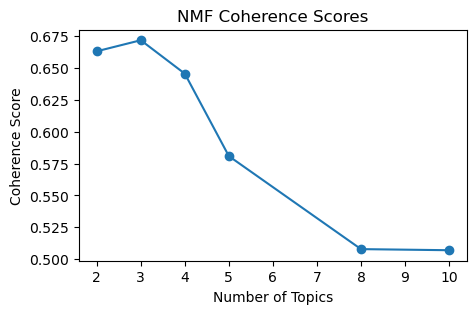

In [37]:
# plotting NMF coherence results

plt.figure(figsize=(5, 3))

plt.plot(
    nmf_results_df["num_topics"],
    nmf_results_df["coherence"],
    marker="o"
)

plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("NMF Coherence Scores")

plt.show()

### Detailed NMF Analysis through Examples

In [38]:
# best NMF models

best_nmf_models = nmf_results_df["num_topics"] \
    .head(TOP_MODELS_TO_INSPECT) \
    .tolist()

print("Best NMF Topic Counts:", best_nmf_models)

Best NMF Topic Counts: [2, 3, 4]


In [39]:
# ======================================================================================
# DETAILED NMF ANALYSIS
# ======================================================================================

for k in best_nmf_models:

    print("\n" + "#" * 100)
    print(f"DETAILED ANALYSIS FOR {k} TOPICS")
    print("#" * 100)

    model = nmf_saved_models[k]["model"]
    topics = nmf_saved_models[k]["topics"]

    print("\nTOPIC KEYWORDS")
    print("=" * 100)

    for i, topic in enumerate(topics):
        print("\n" + "-" * 60)
        print(f"TOPIC {i}")
        print("-" * 60)
        print(", ".join(topic))

    print("\nTOP EXAMPLES")
    print("=" * 100)

    examples = get_topic_examples(
        model,
        nmf_dtm,
        original_comments,
        n_topics=k,
        n_examples=EXAMPLES_PER_TOPIC
    )

    for topic_id, exs in examples.items():

        print("\n" + "-" * 60)
        print(f"TOPIC {topic_id}")
        print("-" * 60)

        for i, text in enumerate(exs, 1):
            print(f"\n{i}. {text}")


####################################################################################################
DETAILED ANALYSIS FOR 2 TOPICS
####################################################################################################

TOPIC KEYWORDS

------------------------------------------------------------
TOPIC 0
------------------------------------------------------------
theme, art, fashion_art, fashion, costume_art, boring, literally, outfits, thought, rose

------------------------------------------------------------
TOPIC 1
------------------------------------------------------------
dress, jisoo, beyonce, lisa, outfit, art, rose, looks_like, blackpink, gorgeous

TOP EXAMPLES

------------------------------------------------------------
TOPIC 0
------------------------------------------------------------

1. What was the theme about?

2. What was the theme?

3. What was the theme

4. Cyborg Theme

5. Because she was not on theme not everything has to about them?

------------

-------

Comparing LDA and NMF results, NMF produces more coherent and clearly separated topics for this dataset. LDA topics show greater overlap and mixing of general conversational terms, whereas NMF yields more distinct groupings that better capture specific discussion threads (e.g., theme-related discourse, celebrity-focused reactions, and outfit commentary). Given this improved interpretability, NMF is selected as the primary topic modelling approach for further analysis, and subsequent sections will focus on deeper exploration of these NMF-derived topics.

-------

### Applying best number of topics to entire dataset

In [43]:
final_k = 4

# re-training NMF model
final_nmf = NMF(
    n_components=final_k,
    random_state=42
)

W = final_nmf.fit_transform(nmf_dtm)
H = final_nmf.components_

# creating dataframe for the comments
processed_comments_df = pd.DataFrame({
    "original_comment": [c["comment_text"] for c in processed_comments],
    "comment_id": [c.get("comment_id") for c in processed_comments]
})

# assigning topic labels to each comment
topic_cols = [f"topic_{i}" for i in range(W.shape[1])]

processed_comments_df = pd.concat(
    [processed_comments_df, pd.DataFrame(W, columns=topic_cols)],
    axis=1
)

# dominant topic
processed_comments_df["topic"] = W.argmax(axis=1)
# score
processed_comments_df["topic_score"] = W.max(axis=1)

## Topic Analysis

### Topic Distribution Analysis

In [46]:
topic_counts = processed_comments_df["topic"].value_counts().sort_index()
total = len(processed_comments_df)

for topic in topic_counts.index:
    count = topic_counts[topic]
    pct = (count / total) * 100
    print(f"Topic {topic}: {count} ({pct:.2f}%)")

Topic 0: 4009 (8.56%)
Topic 1: 32205 (68.80%)
Topic 2: 4417 (9.44%)
Topic 3: 6177 (13.20%)


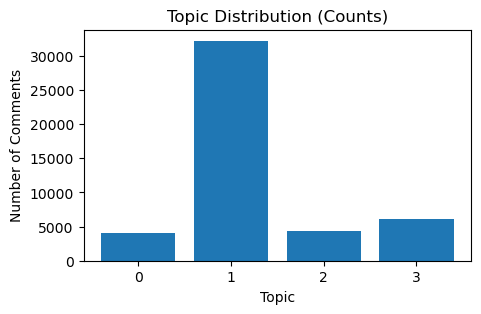

In [47]:
plt.figure(figsize=(5, 3))
plt.bar(topic_counts.index, topic_counts.values)

plt.title("Topic Distribution (Counts)")
plt.xlabel("Topic")
plt.ylabel("Number of Comments")
plt.xticks(topic_counts.index)

plt.show()

### Topic-wise Analysis

#### Helper Functions

In [51]:
# wordcloud
def plot_topic_wordcloud(df, topic_id, text_col="original_comment"):
    text = " ".join(df.loc[df["topic"] == topic_id, text_col].astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="black",
        colormap="Set3",
        random_state=42
    ).generate(text)

    plt.figure(figsize=(5, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id + 1} - Wordcloud")
    plt.show()

In [59]:
# sentiment analysis

SENTIMENT_PROCESSED_VIDEO_DATA_PATH = DATA_DIR / "video_data_sentiment_processed.json"

# finding sentiments from saved file
with open(SENTIMENT_PROCESSED_VIDEO_DATA_PATH, "r", encoding="utf-8") as f:
    sentiment_data = json.load(f)

sentiment_processed_data = sentiment_data["comments"]

# creating sentiment datafram
sentiment_df = pd.DataFrame(sentiment_processed_data)

# keeping only sentiment columns
sentiment_df = sentiment_df[[
    "comment_published_at",
    "comment_id",
    "bert_sentiment",
    "bert_negative",
    "bert_neutral",
    "bert_positive",
    "bert_confidence"
]]

# merging sentiments to current dataframe
processed_comments_df = processed_comments_df.merge(
    sentiment_df,
    on="comment_id",
    how="left"
)

# sanity check
processed_comments_df["bert_sentiment"] = processed_comments_df["bert_sentiment"].fillna("unknown")

In [64]:
# sentiment counts per topic (pos/neg/neutral/unknown)

def get_sentiment_counts(df, topic_id):
    subset = df[df["topic"] == topic_id]
    counts = subset["bert_sentiment"].value_counts(dropna=False)
    return counts


def print_sentiment_counts(df, topic_id):
    counts = get_sentiment_counts(df, topic_id)
    
    print(f"\nTopic {topic_id + 1} sentiment counts:")
    print("-" * 40)
    
    for k, v in counts.items():
        print(f"{k}: {v}")

In [91]:
# top positive & negative comments per topic

def get_top_comments(df, topic_id, sentiment, top_n=3):
    subset = df[
        (df["topic"] == topic_id) &
        (df["bert_sentiment"] == sentiment)
    ]
    
    subset = subset.sort_values("bert_confidence", ascending=False).head(top_n)
    
    return subset


def print_top_comments(df, topic_id):
    def _print_block(subset, title):

        print("-" * 70)
        print(title)
        print("-" * 70)

        for _, row in subset.iterrows():

            score = row.get("bert_confidence", 0.0)
            text = row.get("original_comment", "")

            print(f"\nSCORE: {score:.4f}")
            print("-" * 70)
            print(text)

    # positive
    pos = get_top_comments(df, topic_id, "positive")
    _print_block(pos, "Top Positive examples")

    # negative
    neg = get_top_comments(df, topic_id, "negative")
    print()
    _print_block(neg, "Top Negative examples")

In [99]:
# daily sentiment average 

# mapping
sentiment_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

def plot_daily_sentiment(df, topic_id):

    subset = df[df["topic"] == topic_id].copy()

    subset["comment_published_at"] = pd.to_datetime(subset["comment_published_at"])
    subset["date"] = subset["comment_published_at"].dt.date

    subset["sentiment_score"] = subset["bert_sentiment"].map(sentiment_map)

    daily_avg = subset.groupby("date")["sentiment_score"].mean()

    daily_avg.plot(figsize=(10, 3), title=f"Topic {topic_id + 1} Daily Average Sentiment")
    plt.ylabel("Average Sentiment (-1 to 1)")
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.show()

### Topic 1 - Discourse about Met Gala Theme: "Fashion is Art"

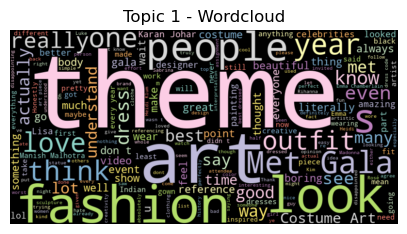

In [52]:
plot_topic_wordcloud(processed_comments_df, topic_id=0)

In [65]:
print_sentiment_counts(processed_comments_df, topic_id=0)


Topic 1 sentiment counts:
----------------------------------------
unknown: 1165
positive: 1108
neutral: 944
negative: 792


In [92]:
print_top_comments(processed_comments_df, topic_id=0)

----------------------------------------------------------------------
Top Positive examples
----------------------------------------------------------------------

SCORE: 0.9913
----------------------------------------------------------------------
This year's met gala theme was so nice (so are the dresses!!)

SCORE: 0.9908
----------------------------------------------------------------------
Our gurls are back ❤❤❤❤🎉

SCORE: 0.9908
----------------------------------------------------------------------
I'm so excited for you ❤❤😊❤😊❤😊❤😊

----------------------------------------------------------------------
Top Negative examples
----------------------------------------------------------------------

SCORE: 0.9593
----------------------------------------------------------------------
How effin dare you Luke? It’s people like you that got us here. smdh

SCORE: 0.9563
----------------------------------------------------------------------
Poor tasted costume party ACK,!! 
WHOM IN THE UNDERG

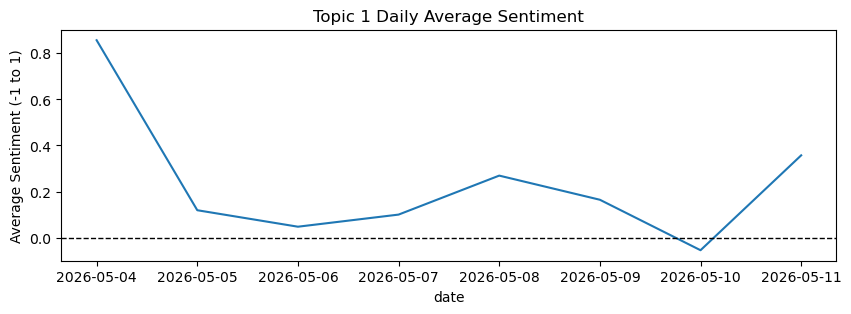

In [100]:
plot_daily_sentiment(processed_comments_df, topic_id=0)

### Topic 2 - General Outfit and Dress Reactions

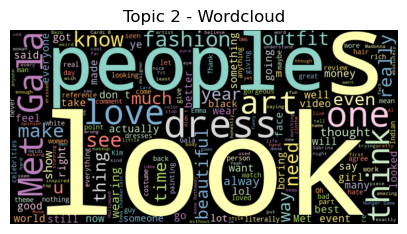

In [53]:
plot_topic_wordcloud(processed_comments_df, topic_id=1)

In [66]:
print_sentiment_counts(processed_comments_df, topic_id=1)


Topic 2 sentiment counts:
----------------------------------------
negative: 9932
unknown: 8913
positive: 8649
neutral: 4711


In [93]:
print_top_comments(processed_comments_df, topic_id=1)

----------------------------------------------------------------------
Top Positive examples
----------------------------------------------------------------------

SCORE: 0.9922
----------------------------------------------------------------------
This episode was so fun. So happy to see Tim back! Glad ro see Rob and Kingsley too! You all look fantastic!

SCORE: 0.9921
----------------------------------------------------------------------
That was soooooo much fun!!!! Thankyou from New Zealand 🖤🤍🖤

SCORE: 0.9919
----------------------------------------------------------------------
I am SO excited for this night with y’all 😃💃
Rob, I love you🫶 You’re totally my favorite and you look so fab as do all of you!

----------------------------------------------------------------------
Top Negative examples
----------------------------------------------------------------------

SCORE: 0.9651
----------------------------------------------------------------------
Wow, this met gala SUCKED! Why 

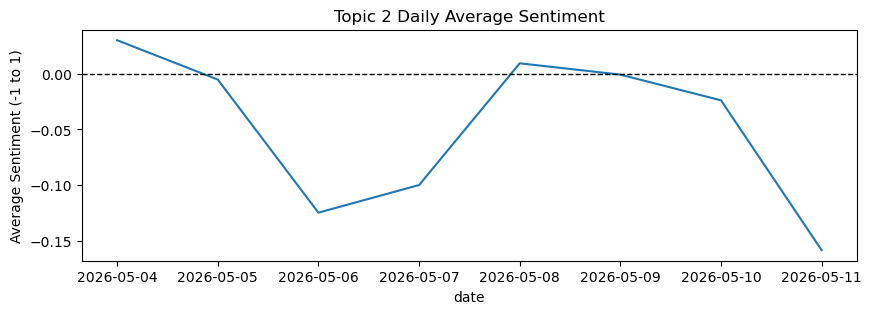

In [101]:
plot_daily_sentiment(processed_comments_df, topic_id=1)

### Topic 3 - BLACKPINK fan discourse & band members-focused reactions

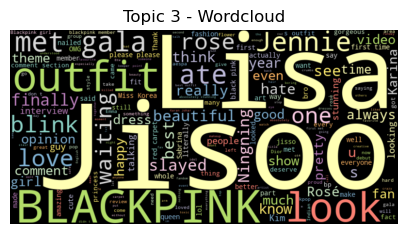

In [54]:
plot_topic_wordcloud(processed_comments_df, topic_id=2)

In [67]:
print_sentiment_counts(processed_comments_df, topic_id=2)


Topic 3 sentiment counts:
----------------------------------------
positive: 2133
unknown: 1007
neutral: 705
negative: 572


In [94]:
print_top_comments(processed_comments_df, topic_id=2)

----------------------------------------------------------------------
Top Positive examples
----------------------------------------------------------------------

SCORE: 0.9925
----------------------------------------------------------------------
Jisoo, we were so happy to see you at this year's Met Gala😻😻

SCORE: 0.9923
----------------------------------------------------------------------
Omg I am very happy to see all the members of blackpink in the met gala 2026.❤❤❤❤❤❤❤

SCORE: 0.9922
----------------------------------------------------------------------
I'm so happy to see Jisoo here!!!And I LOVE Lisa's outfit. 🥹 💕

----------------------------------------------------------------------
Top Negative examples
----------------------------------------------------------------------

SCORE: 0.9560
----------------------------------------------------------------------
OMGGG JENNIE IS IN A COMPETITION IN HERSELF TO HAVE THE WORSTTTTTT OUTFITSS 
SHE HAS A MINDSET OF DOGS TAILS LIKE SHE 

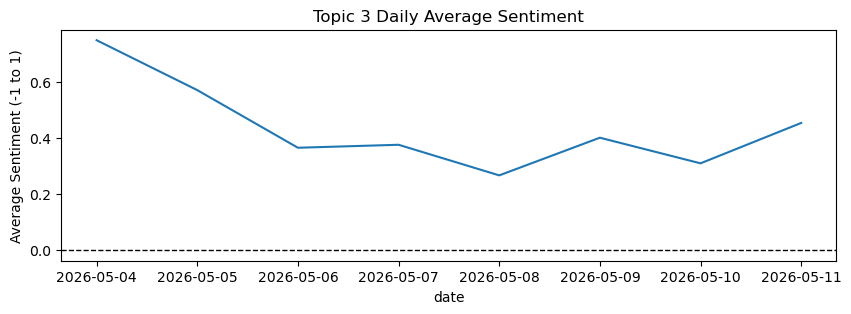

In [102]:
plot_daily_sentiment(processed_comments_df, topic_id=2)

### Topic 4 - Specific Celebrity Red Carpet Looks Reactions

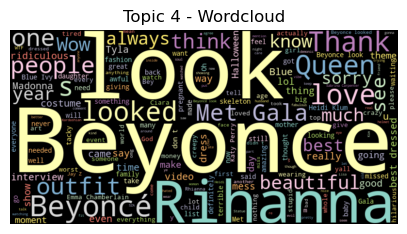

In [55]:
plot_topic_wordcloud(processed_comments_df, topic_id=3)

In [68]:
print_sentiment_counts(processed_comments_df, topic_id=3)


Topic 4 sentiment counts:
----------------------------------------
positive: 2093
negative: 1759
unknown: 1487
neutral: 838


In [95]:
print_top_comments(processed_comments_df, topic_id=3)

----------------------------------------------------------------------
Top Positive examples
----------------------------------------------------------------------

SCORE: 0.9925
----------------------------------------------------------------------
I'm so glad this was the first video I watched today! BEST WAY TO START THE MORNING!!! Hahahaha!! Thanks guys :)

SCORE: 0.9921
----------------------------------------------------------------------
Thank you to see my girls in MetGala, MetGala2026 is wonderful 🖤🩷

SCORE: 0.9913
----------------------------------------------------------------------
Thank you for the fun live!!! ❤ You are the dream panel 🎉

----------------------------------------------------------------------
Top Negative examples
----------------------------------------------------------------------

SCORE: 0.9620
----------------------------------------------------------------------
beyonce looks awful i cant believe it. just stay home, ma’am.

SCORE: 0.9606
-------------

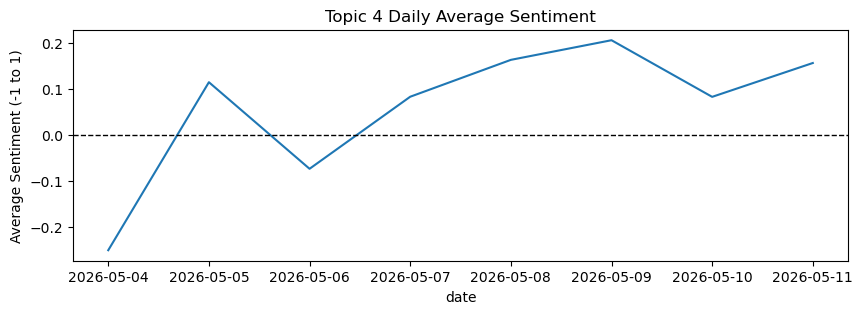

In [103]:
plot_daily_sentiment(processed_comments_df, topic_id=3)